## Following the framework in Truong et al. (2020), a standard CPD pipeline includes five core steps:

- Step 1: Define the signal
- Step 2: Define the type of change
- Step 3: Select the optimization/search method
- Step 4: Determine the number of change points (constraints)
- Step 5: Evaluate and validate the results

Before entering this pipeline, we first prepare the input data.

In [28]:
#!/usr/bin/env python
# coding: utf-8

# ============================================================
# 0. Imports and data loading
# ============================================================
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import ruptures as rpt

In [29]:
# --- 1. Load data ---
DATA_FILE = 'Qualified_hitters_statcast_2021_2025_pa_master.csv'
csv_path = Path(os.getcwd()).parent / 'data' / 'processed' / DATA_FILE
df = pd.read_csv(csv_path)

# --- 2. Data availability summary for the four CPD indicators ---
CPD_INDICATORS = [
    'hitting_decisions_score',
    'power_efficiency',
    'woba_residual',
    'launch_angle_stability_50pa',
]

summary_df = pd.DataFrame({
    'indicator': CPD_INDICATORS,
    'rows_with_value': [df[col].notna().sum() for col in CPD_INDICATORS],
})
summary_df['pct_of_total'] = (summary_df['rows_with_value'] / len(df) * 100).round(2)

print(f"Total rows: {len(df):,}  |  Total batters: {df['batter'].nunique()}")
display(summary_df)

Total rows: 601,449  |  Total batters: 420


,indicator,rows_with_value,pct_of_total
0,hitting_decisions_score,601449,100.00
1,power_efficiency,394994,65.67
2,woba_residual,394994,65.67
3,launch_angle_stability_50pa,383012,63.68


### Step 0: Data Loading & Subdataset Preparation

Before the CPD pipeline, verify data availability and prepare per-indicator subdatasets:

- Load the PA-master CSV and check non-null row counts for all four CPD indicators.
- Use `cpd_subdataset_generator` to slice one player's data into four indicator-specific DataFrames.
- Use `cpd_subdataset_graph_generator` to visually confirm data coverage and signal shape.

Change `SELECTED_PLAYER_ID` to switch players; all downstream steps use the same `cpd_subdatasets` dict.

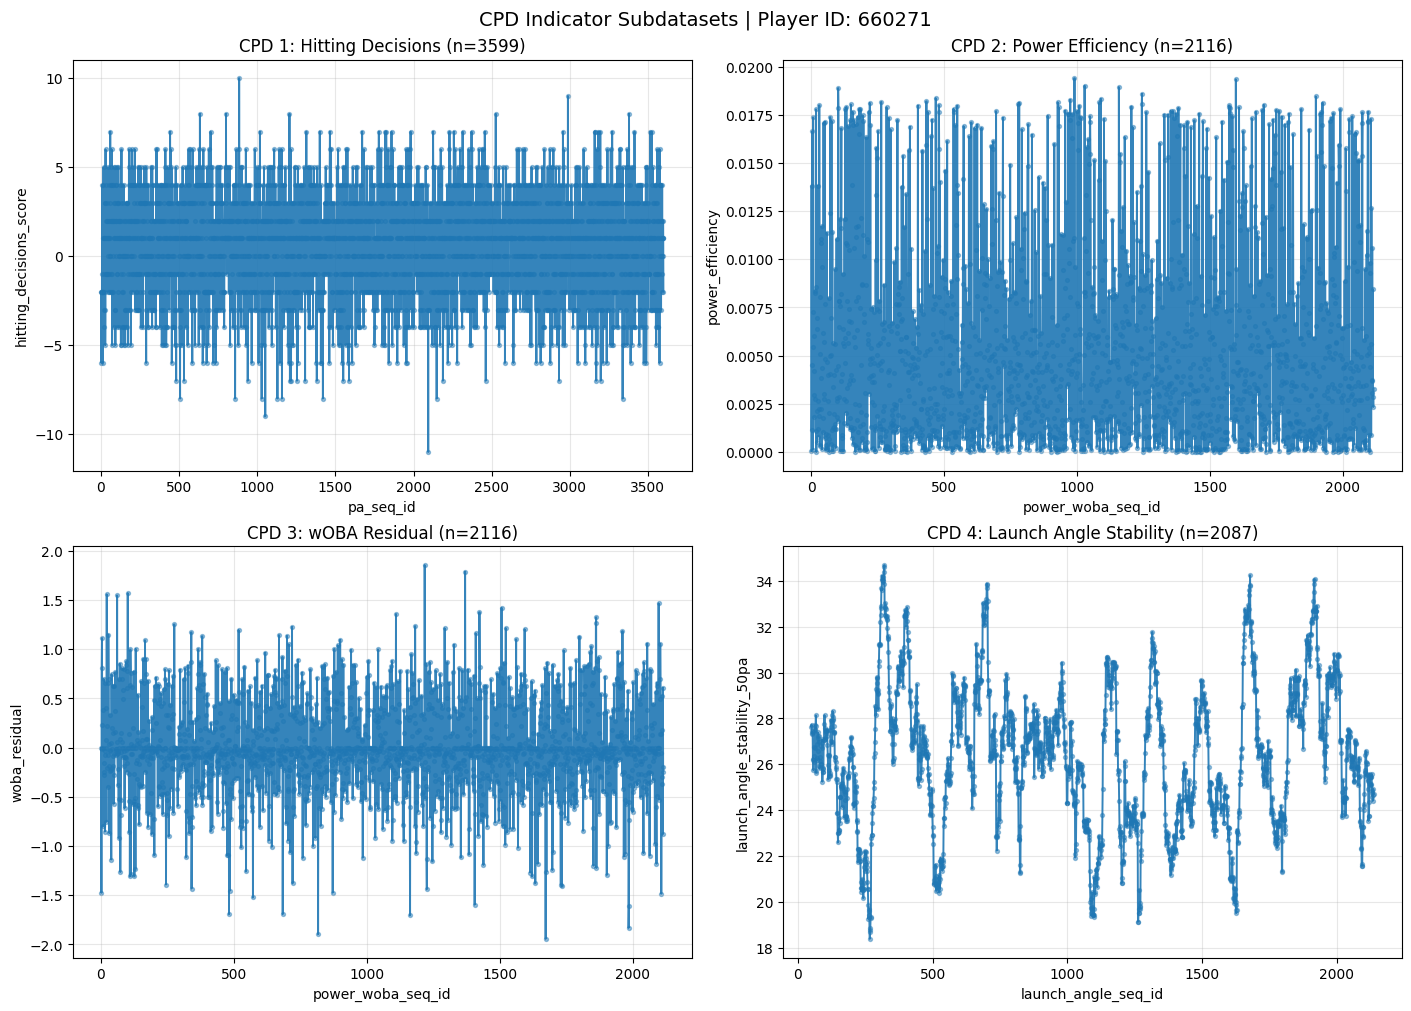

In [ ]:

def cpd_subdataset_generator(df, selected_player_id, window=50, min_periods=1):
    """
    Generate 4 CPD subdatasets for one player, with rolling mean applied.
    """
    base_cols = ["batter", "pa_uid", "game_date", "game_pk", "at_bat_number"]

    def _build_subdataset(x_col, y_col):
        subdf = (
            df.loc[df["batter"] == selected_player_id, base_cols + [x_col, y_col]]
              .dropna(subset=[x_col, y_col])
              .sort_values(x_col)
              .reset_index(drop=True)
        )
        subdf[f"{y_col}_rollmean_{window}"] = (
            subdf[y_col].rolling(window=window, min_periods=min_periods).mean()
        )
        return subdf

    return {
        "decision": _build_subdataset("pa_seq_id", "hitting_decisions_score"),
        "power": _build_subdataset("power_woba_seq_id", "power_efficiency"),
        "woba": _build_subdataset("power_woba_seq_id", "woba_residual"),
        "launch": _build_subdataset("launch_angle_seq_id", "launch_angle_stability_50pa"),
    }

def cpd_subdataset_graph_generator(cpd_subdatasets, selected_player_id=None, window=50, figsize=(14, 10)):
    """
    Plot the 4 CPD subdatasets as a 2x2 panel, showing raw signal and rolling mean.

    Parameters
    ----------
    cpd_subdatasets : dict[str, pandas.DataFrame]
        Output from cpd_subdataset_generator.
    selected_player_id : int | None
        Optional, used for figure title.
    window : int
        Rolling window size used in cpd_subdataset_generator (for column name lookup).
    figsize : tuple[int, int]
        Figure size for matplotlib.

    Returns
    -------
    (fig, axes)
        Matplotlib figure and axes array.
    """
    plot_specs = [
        ("decision", "pa_seq_id", "hitting_decisions_score", "CPD 1: Hitting Decisions"),
        ("power", "power_woba_seq_id", "power_efficiency", "CPD 2: Power Efficiency"),
        ("woba", "power_woba_seq_id", "woba_residual", "CPD 3: wOBA Residual"),
        ("launch", "launch_angle_seq_id", "launch_angle_stability_50pa", "CPD 4: Launch Angle Stability"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)
    axes = axes.flatten()

    for ax, (key, x_col, y_col, title) in zip(axes, plot_specs):
        subdf = cpd_subdatasets.get(key)

        if subdf is None or subdf.empty:
            ax.set_title(f"{title} (no data)")
            ax.set_xlabel(x_col)
            ax.set_ylabel(y_col)
            ax.grid(alpha=0.3)
            continue

        smooth_col = f"{y_col}_rollmean_{window}"

        # raw signal
        ax.plot(subdf[x_col], subdf[y_col], linewidth=1.0, alpha=0.25, color="steelblue", label="raw")
        ax.scatter(subdf[x_col], subdf[y_col], s=6, alpha=0.3, color="steelblue")

        # rolling mean overlay
        if smooth_col in subdf.columns:
            ax.plot(subdf[x_col], subdf[smooth_col], linewidth=2.0, color="orange", label=f"rolling mean (w={window})")

        ax.set_title(f"{title} (n={len(subdf)})")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    fig.suptitle(
        "CPD Indicator Subdatasets" if selected_player_id is None else f"CPD Indicator Subdatasets | Player ID: {selected_player_id}",
        fontsize=14,
    )

    return fig, axes


# Example usage
SELECTED_PLAYER_ID = 660271  # e.g. Shohei Ohtani
cpd_subdatasets = cpd_subdataset_generator(df, SELECTED_PLAYER_ID)

cpd_decision = cpd_subdatasets["decision"]
cpd_power_efficiency = cpd_subdatasets["power"]
cpd_woba_residual = cpd_subdatasets["woba"]
cpd_launch_angle_stability = cpd_subdatasets["launch"]

{
    "cpd_decision_rows": len(cpd_decision),
    "cpd_power_efficiency_rows": len(cpd_power_efficiency),
    "cpd_woba_residual_rows": len(cpd_woba_residual),
    "cpd_launch_angle_stability_rows": len(cpd_launch_angle_stability),
}

fig, axes = cpd_subdataset_graph_generator(cpd_subdatasets, selected_player_id=SELECTED_PLAYER_ID, window=50)
plt.show()


### Step 1: Define the Signal (Implementation Notes)

Prepare a clean, ordered univariate series before CPD:

- Select one player and one indicator at a time.
- Keep only required columns, remove missing values, and sort by sequence index.
- Apply rolling-mean smoothing (window = 50) to reduce noise.
- Build CPD input as shape (n, 1) from the smoothed signal.

Use the same preprocessing rules across indicators for fair comparison.

In [31]:

# ============================================================
# 1. Define the Signal
# ============================================================

def build_signal(subdf, x_col, y_col):
    """
    Build CPD-ready signal.
    """
    signal_df = (
        subdf[[x_col, y_col]]
        .dropna()
        .sort_values(x_col)
        .reset_index(drop=True)
        .copy()
    )
    signal = signal_df[y_col].to_numpy().reshape(-1, 1)
    return signal_df, signal


SELECTED_PLAYER_ID = 660271
WINDOW = 50

cpd_data = cpd_subdataset_generator(df, SELECTED_PLAYER_ID, window=WINDOW)


### Steps 2–4: Change Type, Search Method, and Constraint

Use one model, one search algorithm, and one penalty setting per run:

- **Type of change (cost model)**: `l2` (mean shift), `rbf` (distributional/nonlinear change), `normal` (mean + variance change).
- **Search method**: use `PELT` for efficient global optimization.
- **Constraint**: tune `pen` to control complexity (`pen` lower -> more change points, `pen` higher -> fewer change points).

Start with a moderate penalty, inspect plots, then adjust for interpretability and robustness.

In [3]:
# ============================================================
# 2~4. Type of Change + Search Method + Constraint
# ============================================================

def run_cpd(signal, model="l2", method="pelt", pen=50):
    """
    Run CPD with chosen model / method / penalty.

    Parameters
    ----------
    signal : np.ndarray
        Shape (n, 1)
    model : str
        'l2'     -> mean shift
        'rbf'    -> general distribution / nonlinear changes
        'normal' -> Gaussian mean/variance changes
    method : str
        Currently supports 'pelt'
    pen : int | float
        Penalty controlling number of breakpoints

    Returns
    -------
    bkpts : list[int]
        Breakpoints returned by ruptures
    """
    if method.lower() != "pelt":
        raise ValueError("Currently only method='pelt' is implemented.")

    algo = rpt.Pelt(model=model).fit(signal)
    bkpts = algo.predict(pen=pen)
    return bkpts

### Step 5: Evaluate & Validate (Plotting)

Validate detected change points with visual checks and robustness tests:

- Overlay breakpoints on both raw and smoothed signals.
- Check if breakpoints align with visible level or variability shifts.
- Compare results across `l2`, `rbf`, and `normal` models.
- Re-run with nearby `pen` values to verify stability.

Prefer change points that are both visually supported and interpretable in baseball context.

In [9]:
# ============================================================
# 5. Evaluate & Validate - plotting
# ============================================================

def plot_signal_with_cpd_multi(
    signal_df,
    x_col,
    raw_y_col,
    smooth_y_col,
    bkpts_dict,
    title
):
    """
    Plot CPD results from multiple models with clean legend.

    bkpts_dict example:
    {
        "Mean Shift (L2)": bkpts_l2,
        "Distribution (RBF)": bkpts_rbf,
        "Gaussian (Normal)": bkpts_normal
    }
    """

    fig, ax = plt.subplots(figsize=(14, 5))

    # --- raw & smooth ---
    ax.plot(signal_df[x_col], signal_df[raw_y_col],
            linewidth=1.0, alpha=0.25, label="raw")

    ax.plot(signal_df[x_col], signal_df[smooth_y_col],
            linewidth=2.0, label="rolling mean")

    # --- color mapping ---
    color_map = {
        "Mean Shift (L2)": "red",
        "Distribution (RBF)": "green",
        "Gaussian (Normal)": "purple"
    }

    legend_lines = []

    # --- plot CPD ---
    for name, bkpts in bkpts_dict.items():
        color = color_map.get(name, "black")

        for bp in bkpts[:-1]:
            ax.axvline(
                signal_df.iloc[bp - 1][x_col],
                linestyle="--",
                alpha=0.8,
                color=color
            )

        # create proxy line for legend
        legend_lines.append(
            Line2D([0], [0], color=color, linestyle="--", label=name)
        )

    # --- final legend ---
    ax.legend(handles=ax.get_legend_handles_labels()[0] + legend_lines)

    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(raw_y_col)
    ax.grid(alpha=0.3)

    plt.show()

### Example Running Guide

Run examples in order (Example 1 -> 4) using the same workflow:

- Build `*_plot_df` and `*_signal` from the selected indicator.
- Run `run_cpd` with `l2`, `rbf`, and `normal` models.
- Print internal breakpoint counts for quick comparison.
- Plot all model results together using `plot_signal_with_cpd_multi`.

Keep `WINDOW` fixed and change only `pen` when testing sensitivity.

/Users/irenetsai/Documents/CSE 6242/CSE6242-prj/venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


decision l2 internal bkpts: 1
decision rbf internal bkpts: 5
decision normal internal bkpts: 27


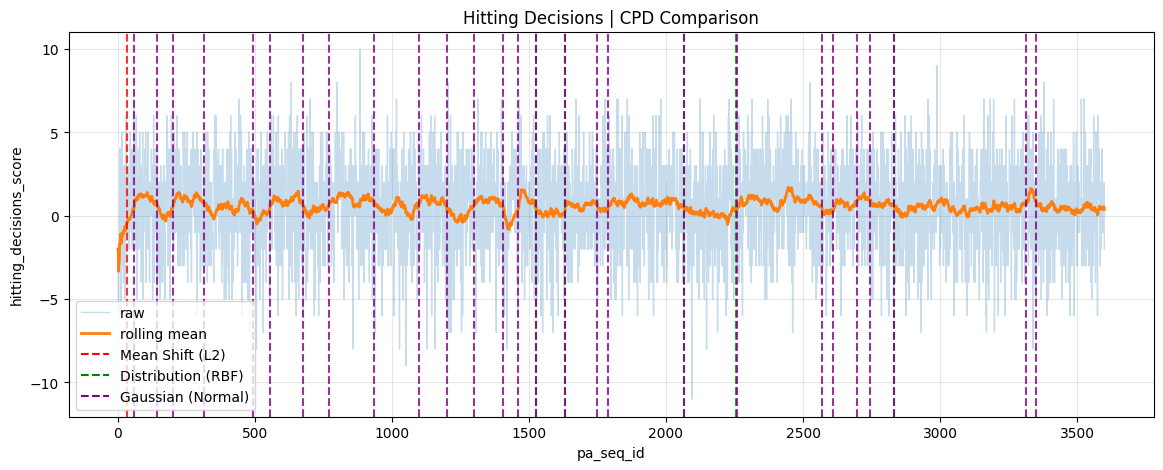

In [12]:
# ============================================================
# Example 1: Hitting Decisions
# ============================================================

decision_raw_col = "hitting_decisions_score"
decision_smooth_col = f"{decision_raw_col}_rollmean_{WINDOW}"

decision_plot_df = (
    cpd_data["decision"][["pa_seq_id", decision_raw_col, decision_smooth_col]]
    .dropna()
    .reset_index(drop=True)
)

decision_signal_df, decision_signal = build_signal(
    decision_plot_df,
    x_col="pa_seq_id",
    y_col=decision_smooth_col
)

decision_bkpts_l2 = run_cpd(decision_signal, model="l2", method="pelt", pen=50)
decision_bkpts_rbf = run_cpd(decision_signal, model="rbf", method="pelt", pen=50)
decision_bkpts_normal = run_cpd(decision_signal, model="normal", method="pelt", pen=100)

print("decision l2 internal bkpts:", len(decision_bkpts_l2) - 1)
print("decision rbf internal bkpts:", len(decision_bkpts_rbf) - 1)
print("decision normal internal bkpts:", len(decision_bkpts_normal) - 1)

plot_signal_with_cpd_multi(
    decision_plot_df,
    x_col="pa_seq_id",
    raw_y_col=decision_raw_col,
    smooth_y_col=decision_smooth_col,
    bkpts_dict={
        "Mean Shift (L2)": decision_bkpts_l2,
        "Distribution (RBF)": decision_bkpts_rbf,
        "Gaussian (Normal)": decision_bkpts_normal
    },
    title="Hitting Decisions | CPD Comparison"
)

power l2 internal bkpts: 0
power rbf internal bkpts: 3
power normal internal bkpts: 13


/Users/irenetsai/Documents/CSE 6242/CSE6242-prj/venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


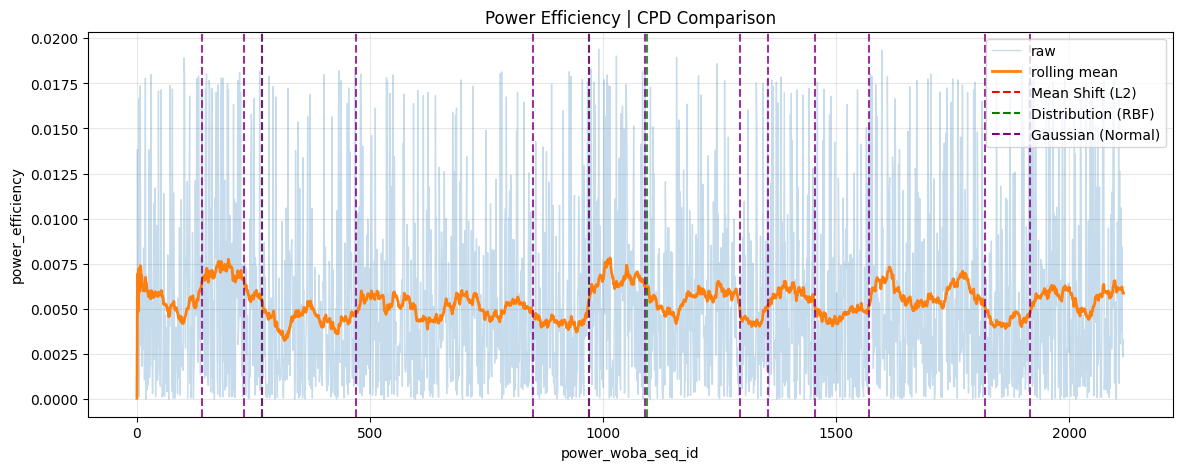

In [17]:
# ============================================================
# Example 2: Power Efficiency
# ============================================================

power_raw_col = "power_efficiency"
power_smooth_col = f"{power_raw_col}_rollmean_{WINDOW}"

power_plot_df = (
    cpd_data["power"][["power_woba_seq_id", power_raw_col, power_smooth_col]]
    .dropna()
    .reset_index(drop=True)
)

power_signal_df, power_signal = build_signal(
    power_plot_df,
    x_col="power_woba_seq_id",
    y_col=power_smooth_col
)

# --- run all 3 models ---
power_bkpts_l2 = run_cpd(power_signal, model="l2", method="pelt", pen=50)
power_bkpts_rbf = run_cpd(power_signal, model="rbf", method="pelt", pen=50)
power_bkpts_normal = run_cpd(power_signal, model="normal", method="pelt", pen=30)

print("power l2 internal bkpts:", len(power_bkpts_l2) - 1)
print("power rbf internal bkpts:", len(power_bkpts_rbf) - 1)
print("power normal internal bkpts:", len(power_bkpts_normal) - 1)

plot_signal_with_cpd_multi(
    power_plot_df,
    x_col="power_woba_seq_id",
    raw_y_col=power_raw_col,
    smooth_y_col=power_smooth_col,
    bkpts_dict={
        "Mean Shift (L2)": power_bkpts_l2,
        "Distribution (RBF)": power_bkpts_rbf,
        "Gaussian (Normal)": power_bkpts_normal
    },
    title="Power Efficiency | CPD Comparison"
)

woba l2 internal bkpts: 0
woba rbf internal bkpts: 0
woba normal internal bkpts: 36


/Users/irenetsai/Documents/CSE 6242/CSE6242-prj/venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


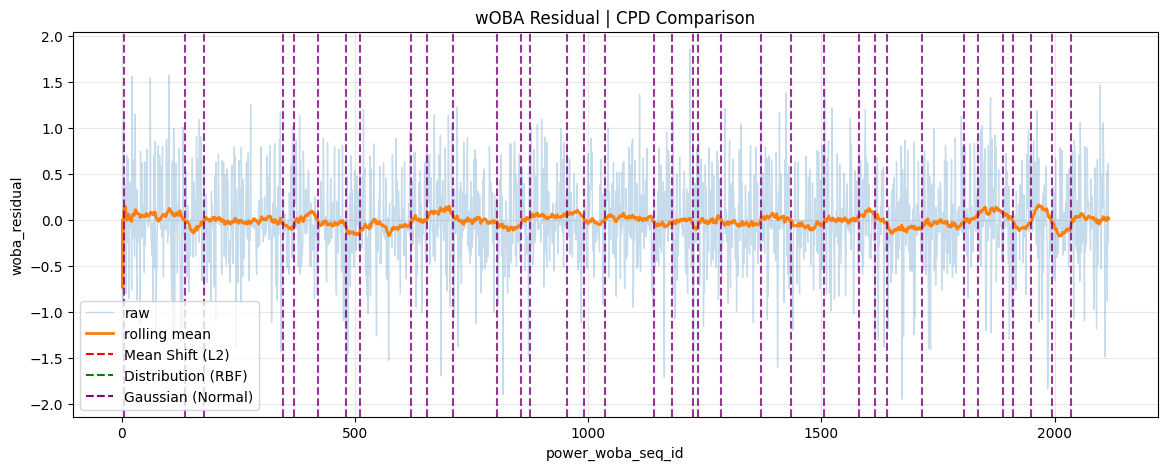

In [14]:
# ============================================================
# Example 3: wOBA Residual
# ============================================================

woba_raw_col = "woba_residual"
woba_smooth_col = f"{woba_raw_col}_rollmean_{WINDOW}"

woba_plot_df = (
    cpd_data["woba"][["power_woba_seq_id", woba_raw_col, woba_smooth_col]]
    .dropna()
    .reset_index(drop=True)
)

woba_signal_df, woba_signal = build_signal(
    woba_plot_df,
    x_col="power_woba_seq_id",
    y_col=woba_smooth_col
)

# --- run all 3 models ---
woba_bkpts_l2 = run_cpd(woba_signal, model="l2", method="pelt", pen=50)
woba_bkpts_rbf = run_cpd(woba_signal, model="rbf", method="pelt", pen=50)
woba_bkpts_normal = run_cpd(woba_signal, model="normal", method="pelt", pen=50)

print("woba l2 internal bkpts:", len(woba_bkpts_l2) - 1)
print("woba rbf internal bkpts:", len(woba_bkpts_rbf) - 1)
print("woba normal internal bkpts:", len(woba_bkpts_normal) - 1)

plot_signal_with_cpd_multi(
    woba_plot_df,
    x_col="power_woba_seq_id",
    raw_y_col=woba_raw_col,
    smooth_y_col=woba_smooth_col,
    bkpts_dict={
        "Mean Shift (L2)": woba_bkpts_l2,
        "Distribution (RBF)": woba_bkpts_rbf,
        "Gaussian (Normal)": woba_bkpts_normal
    },
    title="wOBA Residual | CPD Comparison"
)

launch l2 internal bkpts: 28
launch rbf internal bkpts: 6
launch normal internal bkpts: 23


/Users/irenetsai/Documents/CSE 6242/CSE6242-prj/venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


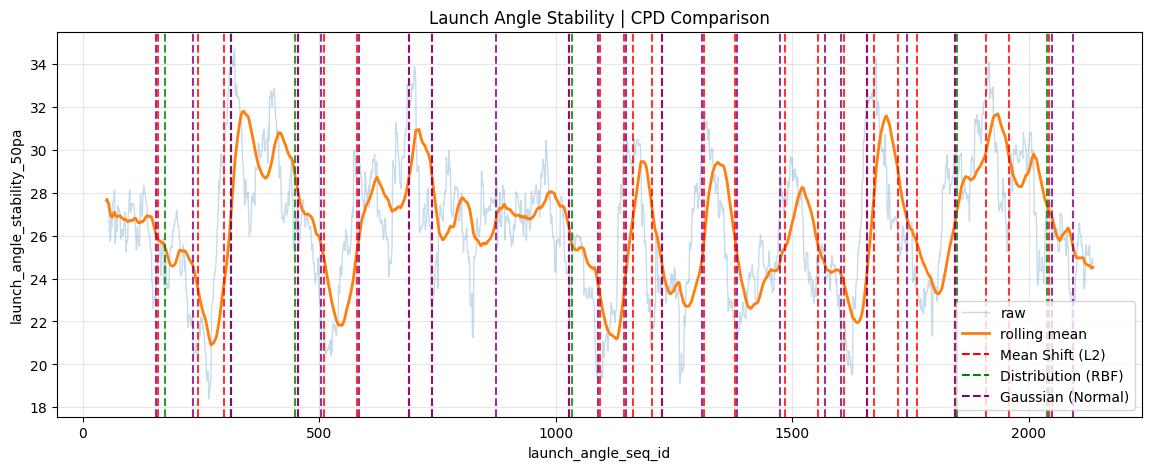

In [16]:
# ============================================================
# Example 4: Launch Angle Stability
# ============================================================

launch_raw_col = "launch_angle_stability_50pa"
launch_smooth_col = f"{launch_raw_col}_rollmean_{WINDOW}"

launch_plot_df = (
    cpd_data["launch"][["launch_angle_seq_id", launch_raw_col, launch_smooth_col]]
    .dropna()
    .reset_index(drop=True)
)

launch_signal_df, launch_signal = build_signal(
    launch_plot_df,
    x_col="launch_angle_seq_id",
    y_col=launch_smooth_col
)

# --- run all 3 models ---
launch_bkpts_l2 = run_cpd(launch_signal, model="l2", method="pelt", pen=50)
launch_bkpts_rbf = run_cpd(launch_signal, model="rbf", method="pelt", pen=50)
launch_bkpts_normal = run_cpd(launch_signal, model="normal", method="pelt", pen=150)

print("launch l2 internal bkpts:", len(launch_bkpts_l2) - 1)
print("launch rbf internal bkpts:", len(launch_bkpts_rbf) - 1)
print("launch normal internal bkpts:", len(launch_bkpts_normal) - 1)

plot_signal_with_cpd_multi(
    launch_plot_df,
    x_col="launch_angle_seq_id",
    raw_y_col=launch_raw_col,
    smooth_y_col=launch_smooth_col,
    bkpts_dict={
        "Mean Shift (L2)": launch_bkpts_l2,
        "Distribution (RBF)": launch_bkpts_rbf,
        "Gaussian (Normal)": launch_bkpts_normal
    },
    title="Launch Angle Stability | CPD Comparison"
)

### 2. Define the Type of Change (Cost Function)

Different cost functions are used to capture different types of structural changes in the signal:

L2 (Least Squares)
Detects changes in the mean level of the signal (mean shift).
RBF (Radial Basis Function)
Captures more general distributional changes, including nonlinear patterns and variance shifts.
Normal Model
Assumes a Gaussian distribution and detects changes in both mean and variance.

Given that some indicators exhibit relatively stable mean but changing variability, models beyond simple mean shift (e.g., RBF, Normal) are considered.

### 3. Choose Optimization Strategy (Search Method)

We adopt the PELT (Pruned Exact Linear Time) algorithm for change point detection.

PELT provides an exact solution to the penalized segmentation problem
It efficiently identifies globally optimal change points
It is suitable for long time series (e.g., thousands of observations)

### 4. Determine Number of Changes (Constraint)

The number of detected change points is controlled by a penalty parameter (pen):

Lower penalty → more change points (risk of overfitting)
Higher penalty → fewer change points (risk of underfitting)

The penalty parameter is tuned to balance sensitivity and interpretability of detected regimes.

### 5. Evaluate & Validate

The detected change points are evaluated using:

Visual inspection
Checking whether change points align with visible shifts in the smoothed signal
Sensitivity analysis
Assessing robustness with respect to:
rolling window size
penalty parameter
Domain interpretation
Verifying whether detected regimes correspond to meaningful changes in player performance or behavior